In [ ]:
!unzip -q "/content/drive/MyDrive/Indonesia Medicinal Plant Dataset.zip" -d "/content/IndoHerb"

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
import matplotlib.pyplot as plt
import numpy as np
import os, shutil, random, pathlib
import zipfile
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

In [ ]:
dataset_path = "/content/IndoHerb"

folders = [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))]
print(f"Total plant species folders: {len(folders)}")
print(folders)
print(f"Total images: {sum([len(os.listdir(os.path.join(dataset_path, f))) for f in folders])}")

Total plant species folders: 100
['Olea Europaea (Zaitun)', 'Aloe Vera (Lidah Buaya)', 'Clitoria Ternatea (Kembang Telang)', 'Orthosiphon Spicatus (Kumis Kucing)', 'Ficus Septica (Awar-Awar)', 'Chrysopogon Zizanioides (Akar Wangi)', 'Euphorbia Tirucalli (Patah Tulang)', 'Selaginella Doederleinii (Paku Rane)', 'Morinda Citrifolia (Mengkudu)', 'Euphoria Longan (Kelengkeng)', 'Alstonia Scholaris (Pulai)', 'Cymbopogon Nardus (Serai)', 'Raulvolvia Serpentina (Pule Pandak)', 'Ocimum Americanum (Selasih)', 'Ziziphus mauritiana Lam. (Bidara)', 'Caesalpinia Sappan L (Secang)', 'Dioscorea Hispida (Gadung)', 'Peperomia Pellucida (Suruhan)', 'Houttoynia Cordata (Amis-Amisan)', 'Psidium Guajava (Jambu Biji)', 'Celosia Cristata (Jengger Ayam)', 'Nepeta Cataria (Catnip)', 'Ruellia Tuberosa (Ceplikan)', 'Blumea Balsamifera (Sembung)', 'Prunus Domestica (Plum)', 'Zingiber Zerumbet (Lempuyang Gajah)', 'Averrhoa Bilimbi (Belimbing Wuluh)', 'Mirabilis Jalapa (Bunga Pukul Empat)', 'Amaranthus Spinosus (Bay

In [ ]:
dataset_path = "/content/IndoHerb"
base_dir = "/content/IndoHerb_split"

if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

In [ ]:
# 60% train, 40% test
for class_folder in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_folder)

    if not os.path.isdir(class_path):
        continue

    images = [img for img in os.listdir(class_path)
             if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

    random.shuffle(images)
    split_idx = int(0.6 * len(images))
    train_imgs = images[:split_idx]
    test_imgs = images[split_idx:]

    os.makedirs(os.path.join(train_dir, class_folder), exist_ok=True)
    os.makedirs(os.path.join(test_dir, class_folder), exist_ok=True)

    for img in train_imgs:
        shutil.copy(os.path.join(class_path, img),
                   os.path.join(train_dir, class_folder, img))
    for img in test_imgs:
        shutil.copy(os.path.join(class_path, img),
                   os.path.join(test_dir, class_folder, img))
print("Dataset split")

Dataset split


In [ ]:
print("Transformations")

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

Transformations


In [ ]:
class PlantDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.classes = sorted([d for d in os.listdir(root_dir)
                             if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}
        self.idx_to_class = {idx: cls_name for cls_name, idx in self.class_to_idx.items()}

        self.image_paths = []
        self.labels = []

        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            images = [os.path.join(class_dir, img) for img in os.listdir(class_dir)
                     if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

            self.image_paths.extend(images)
            self.labels.extend([self.class_to_idx[class_name]] * len(images))

        print(f"Dataset: {len(self.image_paths)} images, {len(self.classes)} classes from {root_dir}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        return image, label

train_dataset = PlantDataset(root_dir=train_dir, transform=train_transform)
test_dataset = PlantDataset(root_dir=test_dir, transform=test_transform)

Dataset: 6000 images, 100 classes from /content/IndoHerb_split/train
Dataset: 4000 images, 100 classes from /content/IndoHerb_split/test


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

class PlantModel:
    def __init__(self, model_name, num_classes):
        self.model_name = model_name
        self.num_classes = num_classes
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        # Load pre-trained model or create scratch model
        if model_name == "resnet34":
            self.model = models.resnet34(pretrained=True)
            num_ftrs = self.model.fc.in_features
            self.model.fc = nn.Linear(num_ftrs, num_classes)

        elif model_name == "densenet121":
            self.model = models.densenet121(pretrained=True)
            num_ftrs = self.model.classifier.in_features
            self.model.classifier = nn.Linear(num_ftrs, num_classes)

        elif model_name == "vgg11":
            self.model = models.vgg11_bn(pretrained=True)
            num_ftrs = self.model.classifier[6].in_features
            self.model.classifier[6] = nn.Linear(num_ftrs, num_classes)

        elif model_name == "scratch_cnn":
            self.model = ScratchCNN(num_classes=num_classes)

        else:
            raise ValueError(f"Unsupported model: {model_name}")

        # Move to device
        self.model.to(self.device)

        # Count trainable parameters
        trainable_params = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        print(f"{model_name} Trainable parameters: {trainable_params:,}")

class ScratchCNN(nn.Module):
    def __init__(self, num_classes=100):
        super(ScratchCNN, self).__init__()

        # Feature extraction layers
        self.features = nn.Sequential(
            # Conv Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # Classifier layers
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128 * 16 * 16, 512),  # 128x128 input -> 16x16 after 3 maxpool layers
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

        # Initialize weights
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.classifier(x)
        return x

# Alternative simpler Scratch CNN (as mentioned in paper)
class SimpleScratchCNN(nn.Module):
    def __init__(self, num_classes=100):
        super(SimpleScratchCNN, self).__init__()

        self.conv_layers = nn.Sequential(
            # Layer 1: 32 filters, 3x3 kernel
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Layer 2: 64 filters, 3x3 kernel
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Layer 3: 128 filters, 3x3 kernel
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),  # Adjusted for 128x128 input
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.classifier(x)
        return x

# Usage example
if __name__ == "__main__":
    # Test all models
    models_to_test = ["resnet34", "densenet121", "vgg11", "scratch_cnn"]

    for model_name in models_to_test:
        print(f"\n=== Testing {model_name} ===")
        try:
            model_wrapper = PlantModel(model_name, num_classes=100)
            print(f"Successfully created {model_name}")

            # Test forward pass
            test_input = torch.randn(2, 3, 128, 128).to(model_wrapper.device)
            output = model_wrapper.model(test_input)
            print(f"Output shape: {output.shape}")

        except Exception as e:
            print(f"Error with {model_name}: {e}")

In [ ]:
class Trainer:
    def __init__(self, model, model_name):
        self.model = model.model
        self.model_name = model_name
        self.device = model.device

        # history
        self.history = {
            'train_loss': [], 'train_acc': [],
            'test_loss': [], 'test_acc': [],
            'precision': [], 'recall': [], 'f1': []
        }

    def train_epoch(self, train_loader, criterion, optimizer):
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(train_loader, desc=f'{self.model_name} Training')
        for batch_idx, (inputs, targets) in enumerate(pbar):
            inputs, targets = inputs.to(self.device), targets.to(self.device)

            # Forward pass
            optimizer.zero_grad()
            outputs = self.model(inputs)
            loss = criterion(outputs, targets)

            # Backward pass
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

            pbar.set_postfix({
                'Loss': f'{running_loss/(batch_idx+1):.3f}',
                'Acc': f'{100.*correct/total:.1f}%'
            })

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100. * correct / total

        return epoch_loss, epoch_acc

    def evaluate(self, test_loader, criterion):
        self.model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        all_preds = []
        all_targets = []

        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(self.device), targets.to(self.device)
                outputs = self.model(inputs)
                loss = criterion(outputs, targets)

                running_loss += loss.item()
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

                all_preds.extend(predicted.cpu().numpy())
                all_targets.extend(targets.cpu().numpy())

        epoch_loss = running_loss / len(test_loader)
        epoch_acc = 100. * correct / total

        precision = precision_score(all_targets, all_preds, average='weighted', zero_division=0)
        recall = recall_score(all_targets, all_preds, average='weighted', zero_division=0)
        f1 = f1_score(all_targets, all_preds, average='weighted', zero_division=0)

        return epoch_loss, epoch_acc, precision, recall, f1

    def train(self, train_loader, test_loader, epochs=50, lr=0.001, gamma=0.9):
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(self.model.parameters(), lr=lr)

        # Learning Rate Scheduler
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

        best_acc = 0.0

        print(f"\ntraining {self.model_name}")
        print(f"   Epochs: {epochs}, Learning Rate: {lr}, Gamma: {gamma}")

        for epoch in range(epochs):
            print(f'\nEpoch {epoch+1}/{epochs}')
            print('-' * 50)

            # Training phase
            train_loss, train_acc = self.train_epoch(train_loader, criterion, optimizer)

            # Evaluation phase
            test_loss, test_acc, precision, recall, f1 = self.evaluate(test_loader, criterion)

            # KEY DIFFERENCE: Update learning rate
            scheduler.step()
            current_lr = scheduler.get_last_lr()[0]

            # Store history
            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            self.history['test_loss'].append(test_loss)
            self.history['test_acc'].append(test_acc)
            self.history['precision'].append(precision)
            self.history['recall'].append(recall)
            self.history['f1'].append(f1)

            # Print progress
            print(f'Precision:  {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}')
            print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
            print(f'Test Loss:  {test_loss:.4f}, Test Acc:  {test_acc:.2f}%')

            # Save best model
            if test_acc > best_acc:
                best_acc = test_acc
                torch.save(self.model.state_dict(), f'{self.model_name}_best.pth')

        # Load best model for final use
        self.model.load_state_dict(torch.load(f'{self.model_name}_best.pth'))
        print(f'\nTraining completed \n Accuracy: {best_acc:.2f}%')

        return best_acc

In [ ]:
print("DataLoader")

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

DataLoader
Train batches: 188, Test batches: 125


In [ ]:
num_classes = len(train_dataset.classes)
print(f"\n🌿 Number of plant classes: {num_classes}")

print("🤖 Initializing models...")
resnet_model = PlantModel("resnet34", num_classes)
densenet_model = PlantModel("densenet121", num_classes)

resnet_trainer = Trainer(resnet_model, "ResNet34")
densenet_trainer = Trainer(densenet_model, "DenseNet121")

# ResNet34
print("\n" + "="*60)
resnet_best_acc = resnet_trainer.train(
    train_loader, test_loader,
    epochs=50, lr=0.001, gamma=0.9
)

# DenseNet121
print("\n" + "="*60)
densenet_best_acc = densenet_trainer.train(
    train_loader, test_loader,
    epochs=50, lr=0.001, gamma=0.9
)


🌿 Number of plant classes: 100
🤖 Initializing models...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-dat

resnet34 Trainable parameters: 21,335,972
densenet121 Trainable parameters: 7,056,356


training ResNet34
   Epochs: 50, Learning Rate: 0.001, Gamma: 0.9

Epoch 1/50
--------------------------------------------------


ResNet34 Training: 100%|██████████| 188/188 [00:16<00:00, 11.10it/s, Loss=3.656, Acc=14.0%]


Precision:  0.1476, Recall: 0.1487, F1: 0.0969
Train Loss: 3.6556, Train Acc: 14.03%
Test Loss:  4.2534, Test Acc:  14.88%

Epoch 2/50
--------------------------------------------------


...

Precision:  0.9072, Recall: 0.9055, F1: 0.9043
Train Loss: 0.0030, Train Acc: 99.97%
Test Loss:  0.4127, Test Acc:  90.55%

Epoch 49/50
--------------------------------------------------


DenseNet121 Training: 100%|██████████| 188/188 [00:26<00:00,  7.16it/s, Loss=0.003, Acc=100.0%]


Precision:  0.9065, Recall: 0.9050, F1: 0.9036
Train Loss: 0.0031, Train Acc: 99.97%
Test Loss:  0.4069, Test Acc:  90.50%

Epoch 50/50
--------------------------------------------------


DenseNet121 Training: 100%|██████████| 188/188 [00:26<00:00,  6.97it/s, Loss=0.002, Acc=100.0%]


Precision:  0.9050, Recall: 0.9032, F1: 0.9020
Train Loss: 0.0024, Train Acc: 99.98%
Test Loss:  0.4134, Test Acc:  90.33%

Training completed 
 Accuracy: 90.65%


1. ResNet34


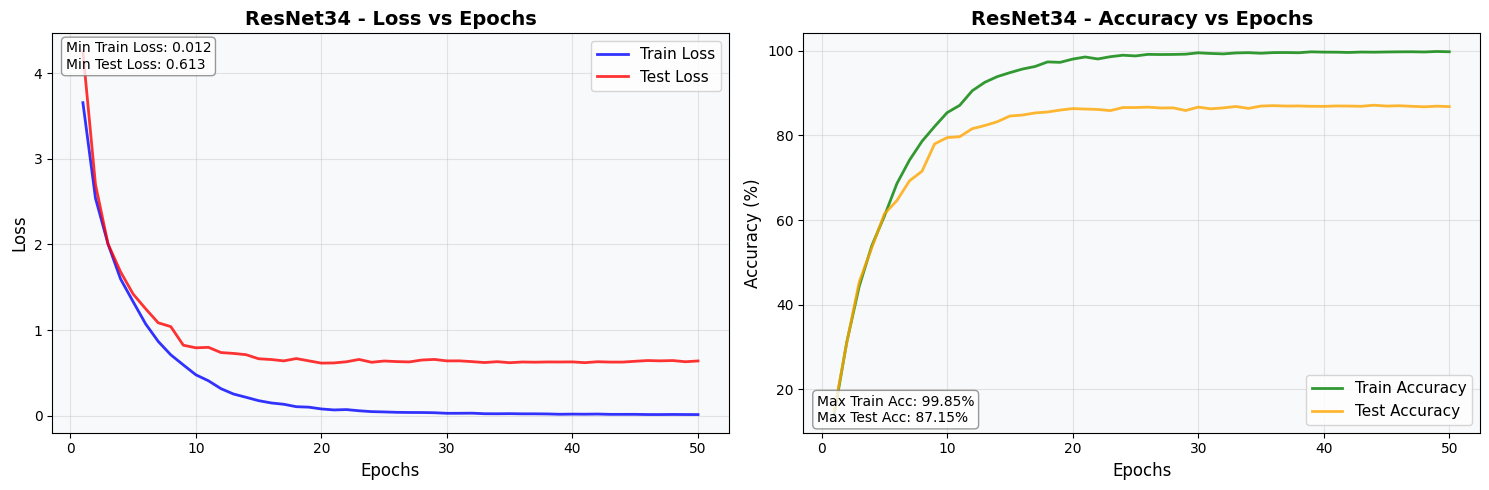


📈 ResNet34 -
   Train Loss: 0.0122
   Train Accuracy: 99.78%
   Test Loss:  0.6385
   Test Accuracy:  86.83%
   Best Test Accuracy:   87.15%

2. DenseNet121


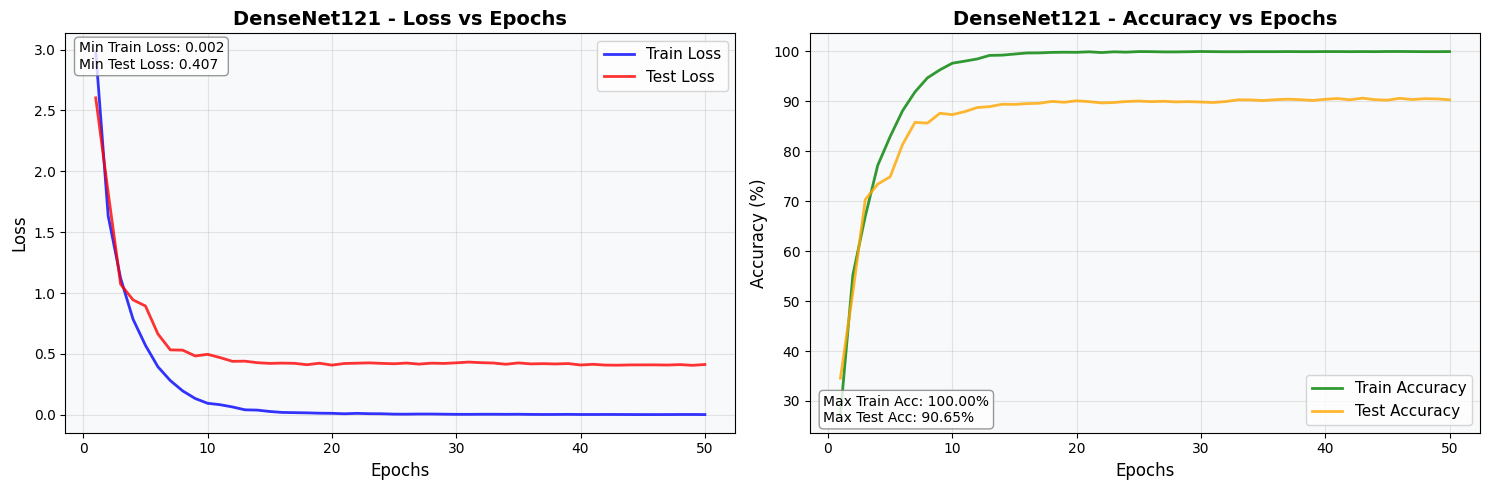


📈 DenseNet121 -
   Train Loss: 0.0024
   Train Accuracy: 99.98%
   Test Loss:  0.4134
   Test Accuracy:  90.33%
   Best Test Accuracy:   90.65%




ResNet34 - Test Accuracy: 87.15%
DenseNet121 - Test Accuracy: 90.65%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_individual_model_history(history, model_name):
    """Plot loss and accuracy for individual model"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    epochs = range(1, len(history['train_loss']) + 1)

    ax1.plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2, alpha=0.8)
    ax1.plot(epochs, history['test_loss'], 'r-', label='Test Loss', linewidth=2, alpha=0.8)
    ax1.set_title(f'{model_name} - Loss vs Epochs', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.set_facecolor('#f8f9fa')

    ax2.plot(epochs, history['train_acc'], 'g-', label='Train Accuracy', linewidth=2, alpha=0.8)
    ax2.plot(epochs, history['test_acc'], 'orange', label='Test Accuracy', linewidth=2, alpha=0.8)
    ax2.set_title(f'{model_name} - Accuracy vs Epochs', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epochs', fontsize=12)
    ax2.set_ylabel('Accuracy (%)', fontsize=12)
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    ax2.set_facecolor('#f8f9fa')

    min_train_loss = min(history['train_loss'])
    min_test_loss = min(history['test_loss'])
    max_train_acc = max(history['train_acc'])
    max_test_acc = max(history['test_acc'])

    ax1.annotate(f'Min Train Loss: {min_train_loss:.3f}\nMin Test Loss: {min_test_loss:.3f}',
                xy=(0.02, 0.98), xycoords='axes fraction',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
                verticalalignment='top', fontsize=10)

    ax2.annotate(f'Max Train Acc: {max_train_acc:.2f}%\nMax Test Acc: {max_test_acc:.2f}%',
                xy=(0.02, 0.02), xycoords='axes fraction',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
                verticalalignment='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

    print(f"\n📈 {model_name} -")
    print(f"   Train Loss: {history['train_loss'][-1]:.4f}")
    print(f"   Train Accuracy: {history['train_acc'][-1]:.2f}%")
    print(f"   Test Loss:  {history['test_loss'][-1]:.4f}")
    print(f"   Test Accuracy:  {history['test_acc'][-1]:.2f}%")
    print(f"   Best Test Accuracy:   {max(history['test_acc']):.2f}%")

print("1. ResNet34")
plot_individual_model_history(resnet_trainer.history, "ResNet34")

print("\n2. DenseNet121")
plot_individual_model_history(densenet_trainer.history, "DenseNet121")

print("\n")
print("\n")
print(f"ResNet34 - Test Accuracy: {resnet_best_acc:.2f}%")
print(f"DenseNet121 - Test Accuracy: {densenet_best_acc:.2f}%")